In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import os
from autoemulate import AutoEmulate
from autoemulate.core.plotting import create_and_plot_slice
from lipb_surrogate import FestimProblem
import sys

/home/kaelyn/anaconda3/envs/tes-pav-env/lib/python3.12/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Reynolds number for LiPb at 0.5m/s is 543615.9929158624.
Schmidt number for LiPb is 144.8770408864817.
Density of LiPb at 603.15K is 9802.2938935kg/m3.
Initial turbulence kinetic energy for LiPb: 0.0009375000000000002 m2/s2
Initial turbulence dissipation rate for LiPb: 3.628235300029708e-05 m2/s3
Initial specific dissipation rate for LiPb: 0.43001307259611343 1/s


In [2]:
simulator = FestimProblem(
    parameters_range={
        "v_in": (0.01, 2.1),
        "c_in": (1e15, 1e25),
    },  # ranges for each variable
    output_names=["c_out", "permeation_flux"],
)

In [5]:
# load training data 
# TODO: make paths generic

X = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/emulator_1/inputs_updated.csv", delimiter=",")
Y = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/emulator_1/outputs.csv", delimiter=",")

In [6]:
# train model 

ae = AutoEmulate(X, Y, log_level="info", models=["GaussianProcessRBF"])
emulator = [r for r in ae.results if r.model_name == "GaussianProcessRBF"][0]

print(f"Selected model: {emulator.model_name} with id: {emulator.id}")

ae.summarize()

INFO    2026-05-06 09:16:38,655 - autoemulate - Comparing ['GaussianProcessRBF']
INFO    2026-05-06 09:16:38,659 - autoemulate - Running Model: GaussianProcessRBF: 1/1 (attempt 1/3)
INFO    2026-05-06 09:17:27,750 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-05-06 09:17:27,751 - autoemulate - Using metric 'r2' to determine best result.
Selected model: GaussianProcessRBF with id: 0


,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
0,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 50, 'lr': 0.5, 'likelihood_cls': <c...",7.822769,64.831238,0.431256,0.105617,0.997267,0.00113,0.060685,0.009783


In [7]:
# save the model
path = "lipb_emulators/emulator_1"
if not os.path.exists(path):
    os.makedirs(path)

emulator_filepath = ae.save(emulator, path, use_timestamp=True)
print("Model and metadata saved to: ", emulator_filepath)

INFO    2026-05-06 09:18:14,227 - autoemulate - GaussianProcessRBF_0_20260506_091814.joblib saved to lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_091814
INFO    2026-05-06 09:18:14,255 - autoemulate - Metadata saved to lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_091814_metadata.csv
Model and metadata saved to:  lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_091814


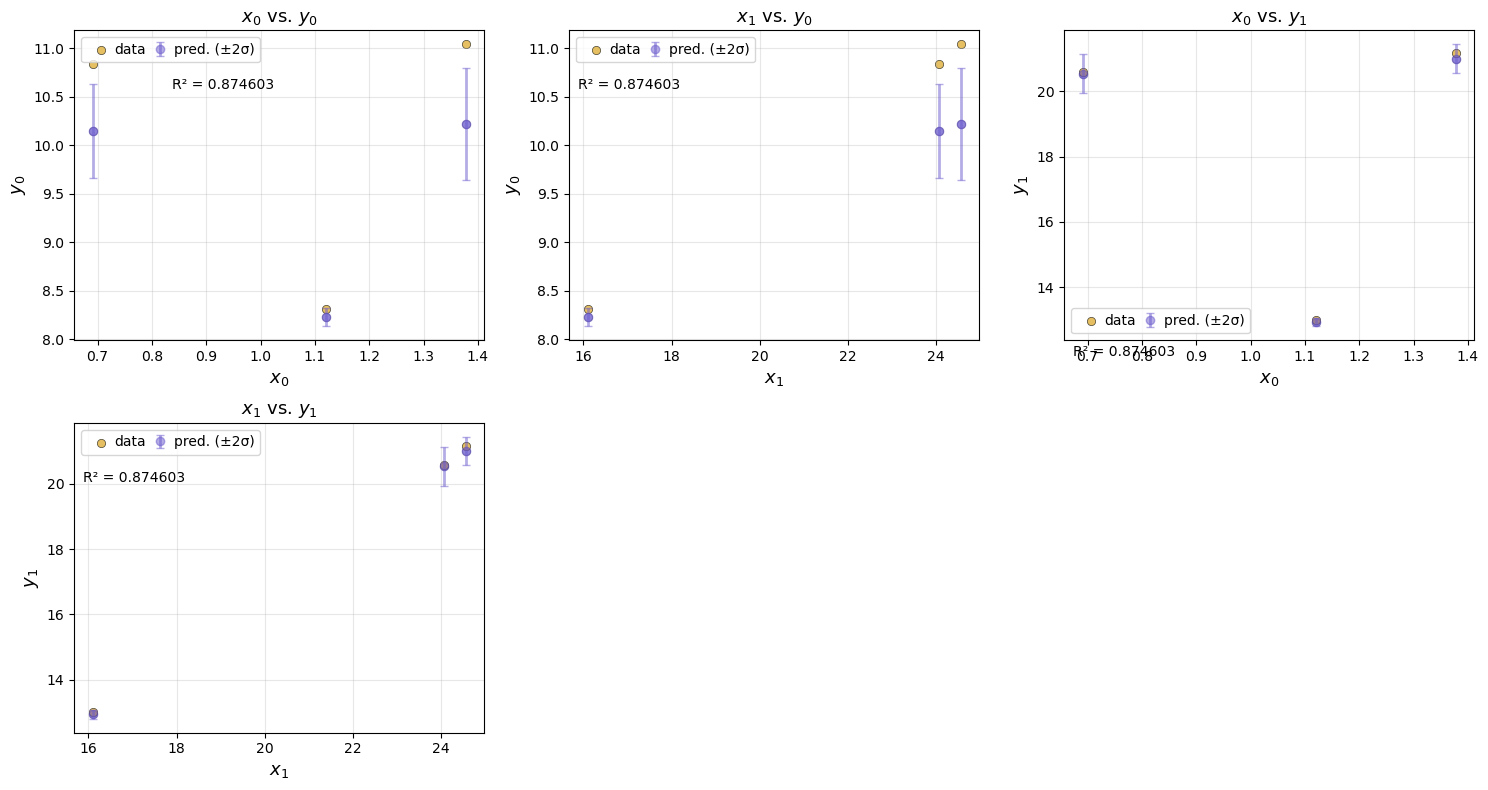

In [8]:
# plotting
ae.plot(emulator)

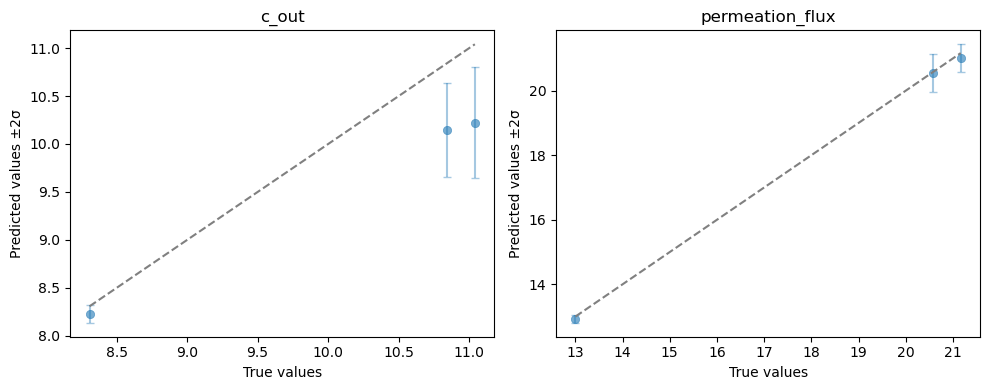

In [9]:
# plot predictions
ae.plot_preds(emulator, output_names=simulator.output_names)

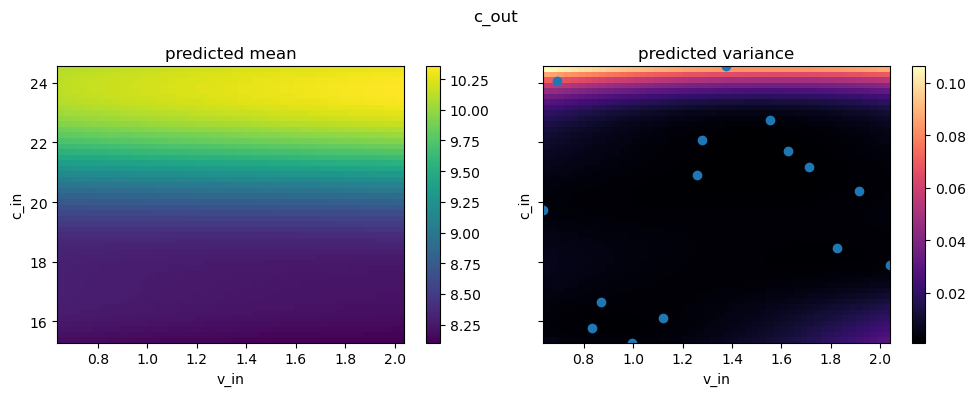

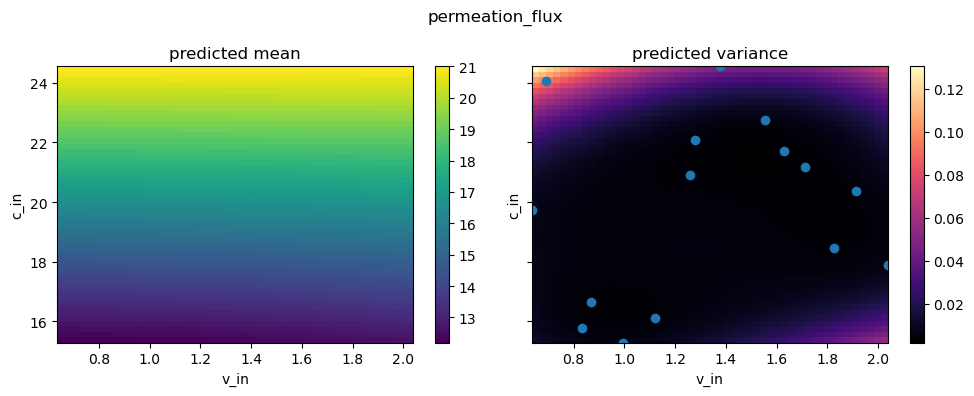

In [ ]:
# plot mean and variance
for i in range(2):
    fig, axs = create_and_plot_slice(
        emulator.model,
        output_idx=i,
        parameters_range={"v_in": (X[:,0].min(), X[:,0].max()), "c_in": (X[:,1].min(), X[:,1].max())}, 
        quantile=0.5,
        param_pair=(0, 1),
    )
    plt.scatter(X[:, 0], X[:, 1])
    plt.suptitle(f"{simulator.output_names[i]}")
